In [1]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as am
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-12 01:47:49,028	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

In [ ]:
df = pd.read_csv('./data/raw/bank.csv')

In [3]:
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


### How many people have opened and not opened new deposit in bank

In [4]:
deposits = df['deposit'].value_counts().reset_index()

deposits.columns = ['deposit', 'number']
deposits['prop'] = deposits['number'] / deposits['number'].sum()

display(deposits)

,deposit,number,prop
0,no,5873,0.52616
1,yes,5289,0.47384


### Remove `collider`

In [5]:
df = df.drop(columns=['duration'])

### Feature engineering

In [6]:
df['has_debt'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int) # długi wpływają na decyzje depozytu

df['net_balance_indicator'] = (df['balance'] > 0).astype(int) # znak salda

In [7]:
df['treatment'] = (df['contact'] == 'cellular').astype(int)

In [8]:
# ryzyko finansowe - confunder
df['financial_stress'] = (
    (df['balance'] < 0) |
    (df['loan'] == 'yes') |
    (df['default'] == 'yes')
).astype(int)

In [9]:
# sezonowość marketingu - confounder
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

df['month_num'] = df['month'].map(month_map)

df = pd.get_dummies(df, columns=['month'], drop_first=True)


In [10]:
# historia kontaktów
# proxy dla propensity score
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)

df['contact_intensity_past'] = df['previous']

In [11]:
df = pd.get_dummies(df, columns=['education','marital'], drop_first=True) # job?

In [12]:
# transofrmacje nieliniowe

# balance
df['balance_shifted'] = df['balance'] - df['balance'].min() + 1 # był NaN dla `x < -1 → log(negative) → NaN ❌`
df['log_balance'] = np.log(df['balance_shifted'])

# age
df['age_squared'] = df['age'] ** 2

In [ ]:
# # log_balance
# df['balance_bin'] = pd.qcut(df['log_balance'], q=20, duplicates='drop').astype(str)

# # age
# df['age_bin'] = pd.qcut(df['age'], q=20, duplicates='drop').astype(str)


In [14]:
# nie  propensity proxy bo działa na campaign ktora jest colliderem
# kontekście estymacji przyczynowego efektu kontaktu jest po-treatment i należy ją wykluczyć.
# - Nie można używać high_campaign w modelu propensity score dla treatment contact.
# # - Nie można używać jako confoundera, bo wprowadziłby post-treatment bias (tzw. collider).
# ❌ Nie używać w causal inference dla contact → deposit
# df['high_campaign'] = (df['campaign'] > df['campaign'].median()).astype(int)

In [19]:
# ----------------------------
# USUWANIE ZBĘDNYCH KOLUMN
# ----------------------------

columns_to_drop = [
    'balance',        # zastąpione przez log_balance, balance_shifted, net_balance_indicator
    'housing',        # połączone w has_debt i financial_stress
    'loan',           # połączone w has_debt i financial_stress
    'default',        # połączone w financial_stress
    'education',      # zastąpione przez dummies: education_secondary, education_tertiary, education_unknown
    'marital',        # zastąpione przez dummies: marital_married, marital_single
    'month',          # zastąpione przez dummies month_2 ... month_12
    'duration',       # collider / post-treatment
    'campaign',       # post-treatment
]

# kolumny, które są już w prop score lub po transformacjach
# pdays -> was_contacted_before
# previous -> contact_intensity_past
# contact -> treatment (możesz zostawić lub całkowicie usunąć)
# age zostawiamy jeśli chcemy razem z age_squared i age_bin

df = df.drop(columns=columns_to_drop, errors='ignore')  # errors='ignore' chroni przed KeyError

# ----------------------------
# Finalny zbiór zmiennych
# ----------------------------
print("Finalne kolumny zbioru:")
print(df.columns.tolist())

Finalne kolumny zbioru:
['age', 'job', 'contact', 'day', 'pdays', 'previous', 'poutcome', 'deposit', 'has_debt', 'net_balance_indicator', 'treatment', 'financial_stress', 'month_num', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'was_contacted_before', 'contact_intensity_past', 'education_secondary', 'education_tertiary', 'education_unknown', 'marital_married', 'marital_single', 'balance_shifted', 'log_balance', 'age_squared', 'deposit_numeric']


In [20]:
df.glimpse()

<class 'pandas.DataFrame'>: 11162 rows of 35 columns
age:                     int64             [59, 56, 41, 55, 54, 42, 56,  ...
job:                     str               ['admin.', 'admin.', 'technic ...
contact:                 str               ['unknown', 'unknown', 'unkno ...
day:                     int64             [5, 5, 5, 5, 5, 5, 6, 6, 6, 6 ...
pdays:                   int64             [-1, -1, -1, -1, -1, -1, -1,  ...
previous:                int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0 ...
poutcome:                str               ['unknown', 'unknown', 'unkno ...
deposit:                 str               ['yes', 'yes', 'yes', 'yes',  ...
has_debt:                int64             [1, 0, 1, 1, 0, 1, 1, 1, 1, 1 ...
net_balance_indicator:   int64             [1, 1, 1, 1, 1, 0, 1, 1, 1, 1 ...
treatment:               int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0 ...
financial_stress:        int64             [0, 0, 0, 0, 0, 1, 1, 0, 0, 0 ...
month_num:             

### Corelation Analyse

In [21]:

df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

df_bins = df[['deposit_numeric', 'balance_bin', 'age_bin']].copy()

# Konwertujemy Interval → string
for col in ['balance_bin', 'age_bin']:
    df_bins[col] = df_bins[col].astype(str)

corr_list = []
for feature in ['balance_bin', 'age_bin']:
    df_grouped = df_bins.groupby(feature)['deposit_numeric'].mean().reset_index()
    df_grouped.columns = ['bin', 'correlation']
    df_grouped['feature'] = feature.replace('_bin', '')
    corr_list.append(df_grouped)

df_correlated_full = pd.concat(corr_list, ignore_index=True)

# Plot funnel
import plotly.express as px
fig = px.scatter(
    df_correlated_full,
    x='correlation',
    y='bin',
    color='feature',
    hover_data=['feature', 'bin', 'correlation']
)
fig.show()

KeyError: "['balance_bin', 'age_bin'] not in index"

1️⃣ Oś X – korelacja

* To jest P(deposit) w danym binie – wyższa wartość oznacza, że w tym przedziale więcej osób otworzyło depozyt.
* Kropki przesunięte w prawo → wysoka korelacja między binem a depozytem.

2️⃣ Oś Y – biny

* Każdy bin pokazuje zakres wartości cechy.

  * `balance` (log_balance) w przedziałach np. `(8.833, 8.841]`, `(8.859, 8.869]` – im wyżej na osi Y, tym wyższy przedział salda (wyższe log_balance).
  * `age` w przedziałach np. `(26.0, 28.0]`, `(31.0, 32.0]` – im wyżej na osi Y, tym starsze osoby.

---

#### **Balance / log_balance (niebieskie)**

* Trend rosnący w poziomie → wyższe log_balance wiąże się z wyższym P(deposit).
* Czyli **saldo jest silnym predyktorem**: osoby z wyższym saldem częściej otwierają depozyt.
* Warto uwzględnić w modelu causal lub propensity score, bo to **potencjalny confounder**.

#### **Age (czerwone)**

* Również trend rosnący → starsi klienci mają większe prawdopodobieństwo depozytu w tym zestawie danych.
* Efekt umiarkowany – korelacja nie tak silna jak dla salda, ale sensowna.
* Można uwzględnić w modelu jako **zmienną kontrolną** (age biny lub age_squared).

---

* Biny przesunięte mocno w prawo → wysoki P(deposit) → istotne do uwzględnienia.
* W praktyce możesz wybrać:

  * Dla `log_balance`: biny `(8.893, 8.909]` i wyżej, gdzie korelacja >0.5
  * Dla `age`: biny `(52.0, 55.0]` i wyżej (korelacja >0.45–0.5)
* Te biny pokazują, że **efekt jest najsilniejszy w tych przedziałach** → warto je modelować jako nieliniową zmienną (np. w regression splines lub quantile bins w modelu).


1. **Balance** → silny, liniowy trend. Zdecydowanie do uwzględnienia.
2. **Age** → umiarkowy trend, ale sensowny, szczególnie starsze grupy.
3. **Model causal** → użyj obu cech:

   * `log_balance` → główny confounder
   * `age` → zmienna kontrolna, można nieliniowo lub jako biny
4. Możesz też **połączyć oba w propensity score**, żeby lepiej balansować grupy treatment / control.


<Axes: xlabel='balance_bin'>

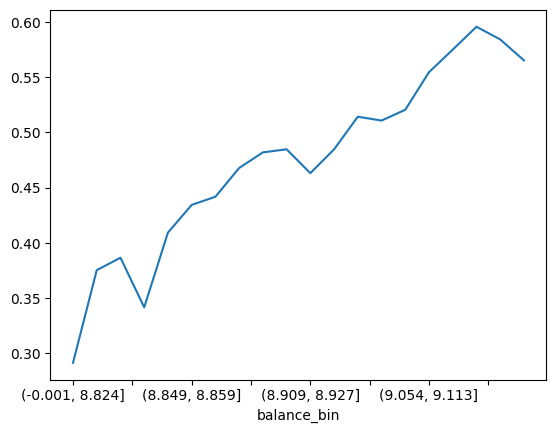

In [18]:
# # P(deposit=1 | X)
# # X: log_balance
# # Y: P(deposit=1)

# df['balance_bin'] = pd.qcut(df['log_balance'], q=20)

plot_df = df.groupby('balance_bin')['deposit'].apply(lambda x: (x=='yes').mean())
plot_df.plot()

<Axes: xlabel='age_bin'>

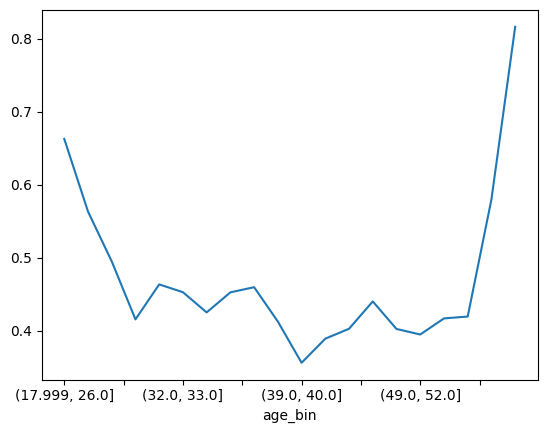

In [19]:
# df['age_bin'] = pd.qcut(df['age'], q=20)

plot_df = df.groupby('age_bin')['deposit'].apply(lambda x: (x=='yes').mean())
plot_df.plot()
# U-shape / inverted U:
# młodzi ↓
# średni wiek ↑
# starsi ↓

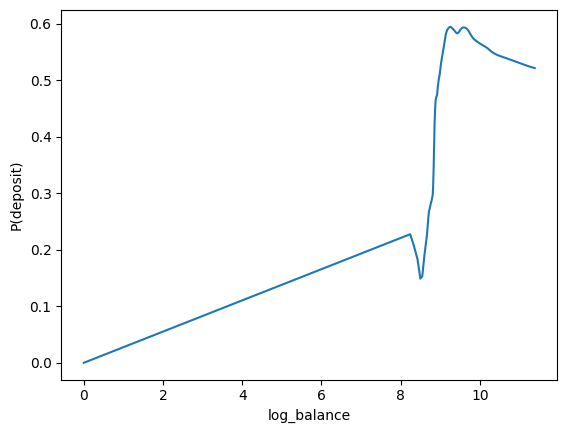

In [20]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
y = (df['deposit']=='yes').astype(int)

lowess = sm.nonparametric.lowess(y, df['log_balance'], frac=0.3)

plt.plot(lowess[:,0], lowess[:,1])
plt.xlabel('log_balance')
plt.ylabel('P(deposit)')
plt.show()
# rosnąca krzywa → bogatsi częściej kupują depozyt
# plateau → efekt nasycenia

<Axes: xlabel='balance_bin'>

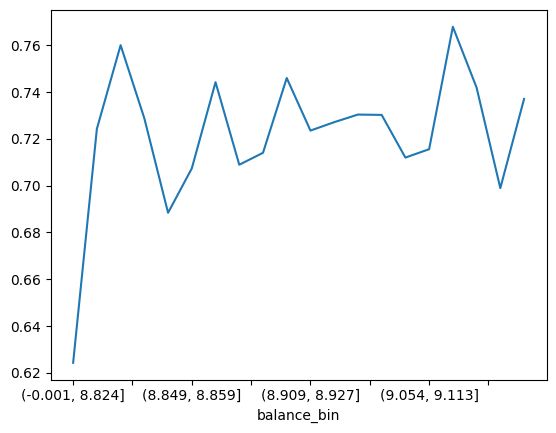

In [21]:
# # P(T=1 | X)
# # (df.groupby('balance_bin')['treatment'].mean()).plot()
plot_df = df.groupby('balance_bin')['treatment'].mean()
plot_df.plot()

In [22]:
# jakies grupowanie aktegorii z job ?
df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)


In [22]:
# 1. Korelacja dla cech binarnych vs target
binary_cols = [c for c in df.columns if df[c].dtype == 'bool' or (df[c].dtype == 'int64' and df[c].nunique() == 2)]
binary_cols = [c for c in binary_cols if c != 'deposit_numeric']

X_bin = df[binary_cols].astype(int)
y_bin = df['deposit_numeric']

from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(X_bin, y_bin)

chi_df = pd.DataFrame({
    'feature': binary_cols,
    'chi2': chi_scores,
    'p_value': p_values
}).sort_values(by='chi2', ascending=False)

print(chi_df.head(20))

                  feature        chi2       p_value
15   was_contacted_before  443.598786  1.783277e-98
0                has_debt  282.098055  2.620593e-63
11              month_may  242.407391  1.174350e-54
10              month_mar  199.685434  2.446118e-45
13              month_oct  192.761120  7.937076e-44
3        financial_stress  189.401853  4.294323e-43
14              month_sep  174.615519  7.263867e-40
2               treatment  155.505749  1.085609e-35
5               month_dec   83.583952  6.106680e-20
20         marital_single   68.453963  1.298745e-16
17     education_tertiary   66.874790  2.893111e-16
19        marital_married   40.859643  1.635642e-10
6               month_feb   27.771562  1.365181e-07
8               month_jul   21.647053  3.277131e-06
16    education_secondary   15.346350  8.949367e-05
1   net_balance_indicator   15.046142  1.049145e-04
12              month_nov    8.171475  4.255430e-03
7               month_jan    5.142421  2.334806e-02
9           

#### 1️⃣ Silne korelacje – sensowne do uwzględnienia

| Feature                                            | chi²    | p-value       | Interpretacja                                                                                                                                                               |
| -------------------------------------------------- | ------- | ------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `was_contacted_before`                             | 443.6   | 1.78e-98      | Absolutnie kluczowy. Silna korelacja i logiczny mechanizm – osoby wcześniej kontaktowane częściej otwierają depozyt → **można używać w propensity score / regresji causal** |
| `has_debt`                                         | 282.1   | 2.62e-63      | Silna korelacja – finansowe obciążenie zmienia decyzję → **confounder do kontroli**                                                                                         |
| `month_may`, `month_mar`, `month_oct`, `month_sep` | 175–242 | 1e-54 → 7e-40 | Silny efekt sezonowy, kontroluj jako moderator/interakcję w modelu causal                                                                                                   |
| `financial_stress`                                 | 189.4   | 4.29e-43      | Bezpośredni mechanizm: saldo negatywne lub kredyt zmienia decyzję → **confounder**                                                                                          |
| `treatment`                                        | 155.5   | 1.08e-35      | Bezpośredni **efekt interwencyjny**, czyli wprost causal → kluczowy w modelu                                                                                                |

➡ Te cechy **mają sens zarówno statystycznie, jak i logicznie**, można je stosować w modelach do kontroli confounderów lub do propensity score.

---

#### 2️⃣ Średnia korelacja – można stosować, ale ostrożnie

| Feature                                                                | chi²  | p-value       |                                                                                                                                     |
| ---------------------------------------------------------------------- | ----- | ------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| `month_dec`, `marital_single`, `education_tertiary`, `marital_married` | 40–83 | 1e-20 → 1e-10 | Są skorelowane, ale efekt słabszy. Można użyć w modelach, ale **nie są krytyczne**. W causal mogą pełnić rolę **effect modifiers**. |

---

#### 3️⃣ Słaba korelacja – zazwyczaj ignorujemy

| Feature                  | chi² | p-value  |                                                                                                                              |
| ------------------------ | ---- | -------- | ---------------------------------------------------------------------------------------------------------------------------- |
| `month_jun`, `month_aug` | <10  | 0.05–0.1 | Korelacja praktycznie zerowa – **nie warto wprowadzać do modeli causal**. Nie wniosą informacji, mogą tylko wprowadzać szum. |

---

### 🔹 Reguła praktyczna w causal analytics

1. **Minimalna korelacja/statystyczna istotność** → warunek konieczny (chi² wysokie, p<0.05).
2. **Logiczny mechanizm** → feature powinna mieć uzasadnienie w świecie realnym (czy wpływa na outcome lub treatment).
3. **Nie każda cecha z danymi** → nie wszystkie można wrzucić do modelu.

   * Jeśli cecha nie ma korelacji ani logicznego powiązania → nie używamy.
4. **Confounders vs moderators vs treatment** → klasyfikacja cech w kontekście causal, zależnie od ich funkcji.

---

💡 Wniosek:

* Silne chi² (>100) → jasny kandydat do modeli causal.
* Średnie chi² (10–100) → można stosować ostrożnie jako kontrolę lub efekt modyfikujący.
* Słabe chi² (<10) → ignorować w modelu.

In [24]:
# 2. Korelacja dla cech numerycznych vs target
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'deposit_numeric']

corrs = df[numeric_cols + ['deposit_numeric']].corr()['deposit_numeric'].drop('deposit_numeric')
corrs = corrs.sort_values(key=abs, ascending=False)
print(corrs.head(20))

has_debt                 -0.231671
was_contacted_before      0.230850
treatment                 0.223252
pdays                     0.151593
financial_stress         -0.143693
previous                  0.139867
contact_intensity_past    0.139867
log_balance               0.110317
net_balance_indicator     0.101447
balance_shifted           0.081129
age_squared               0.064768
day                      -0.056326
age                       0.034901
month_num                 0.028645
Name: deposit_numeric, dtype: float64


#### 1️⃣ Najsilniejsze korelacje

| Feature                | Corr   | Interpretacja                                                                                                                           |
| ---------------------- | ------ | --------------------------------------------------------------------------------------------------------------------------------------- |
| `has_debt`             | -0.232 | Osoby z długiem mają mniejszą szansę na otwarcie depozytu → **silny confounder**                                                        |
| `was_contacted_before` | 0.231  | Najsilniejszy pozytywny efekt – kontakt w przeszłości zwiększa szansę na depozyt → **ważny predyktor, potencjalnie w propensity score** |
| `treatment`            | 0.223  | Bezpośredni efekt interwencji (czy był kontakt) → **właściwy treatment w analizie causal**                                              |

---

#### 2️⃣ Średnie korelacje

| Feature                               | Corr   | Interpretacja                                                                               |
| ------------------------------------- | ------ | ------------------------------------------------------------------------------------------- |
| `pdays`                               | 0.152  | Liczba dni od ostatniego kontaktu – efekt umiarkowany, logiczny mechanizm                   |
| `financial_stress`                    | -0.144 | Negatywny wpływ ryzyka finansowego → może być confounderem                                  |
| `previous` / `contact_intensity_past` | 0.140  | Historia kontaktów – proxy dla prawdopodobieństwa odpowiedzi → użyteczne w propensity score |
| `log_balance`                         | 0.110  | Wyższe saldo zwiększa szansę na depozyt, efekt umiarkowany                                  |
| `net_balance_indicator`               | 0.101  | Czy saldo dodatnie – słabszy efekt, ale sensowny                                            |

---

#### 3️⃣ Słabe korelacje (praktycznie zerowe)

| Feature           | Corr   |
| ----------------- | ------ |
| `balance_shifted` | 0.081  |
| `age_squared`     | 0.065  |
| `day`             | -0.056 |
| `age`             | 0.035  |
| `month_num`       | 0.029  |

➡ Wartość korelacji <0.1 oznacza, że **te cechy nie mają praktycznie żadnego liniowego związku z outcome**. W analizie causal nie będą ani confounderami, ani mocnymi predyktorami – chyba że mamy powód, żeby wprowadzić je jako **efekt nieliniowy** (np. w splines w modelach regresyjnych).

---

### 🔹 Wnioski dla causal analytics

1. **Silne korelacje (>0.2)** → `has_debt`, `was_contacted_before`, `treatment` → **kluczowe do modelu**.
2. **Średnie korelacje (0.1–0.2)** → `pdays`, `financial_stress`, `previous`, `contact_intensity_past`, `log_balance`, `net_balance_indicator` → **warto użyć, szczególnie jako confounders w propensity score lub regresji**.
3. **Słabe korelacje (<0.1)** → `age`, `day`, `month_num`, `balance_shifted` → można pominąć w prostych modelach causal, chyba że model dopuszcza nieliniowość lub interakcje.


In [25]:
for feature in ['balance_bin', 'age_bin']:
    df_plot = df.groupby(feature)['deposit_numeric'].mean().reset_index()
    df_plot.rename(columns={'deposit_numeric':'correlation'}, inplace=True)
    df_plot['feature'] = feature.replace('_bin', '')
    df_plot['bin'] = df_plot[feature]
    
    import plotly.express as px
    fig = px.scatter(df_plot, x='correlation', y='bin', color='feature', hover_data=['bin','correlation'])
    fig.show()

In [ ]:
import pandas as pd
import numpy as np
import pytimetk as tk

# Target numeric
df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

# Bucketowane kolumny → zamień na średnią wartość targetu w binie
bucket_cols = ['balance_bin', 'age_bin']

for col in bucket_cols:
    mean_target = df.groupby(col)['deposit_numeric'].transform('mean')
    df[col + '_num'] = mean_target  # nowa kolumna numeric

# 2. Only numeric + bool
df_clean = df.select_dtypes(include=['number', 'bool']).copy()

# 3. Usuń duolikaty kolumny
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# 4. Bool → int
bool_cols = df_clean.select_dtypes('bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# 5. Reset index
df_clean = df_clean.reset_index(drop=True)

# Correlation (manual)
corrs = df_clean.corr(numeric_only=True)['deposit_numeric'].drop('deposit_numeric')

df_correlated = corrs.reset_index()
df_correlated.columns = ['feature_full', 'correlation']

df_correlated[['feature', 'bin']] = df_correlated['feature_full'].str.split('_', n=1, expand=True)
df_correlated['bin'] = df_correlated['bin'].fillna(df_correlated['feature_full'])

# Top 30
df_correlated_top = df_correlated.nlargest(30, 'correlation')

# Plot
funnel = df_correlated_top.plot_correlation_funnel(
    engine='plotly',
    height=600
)
funnel.show()

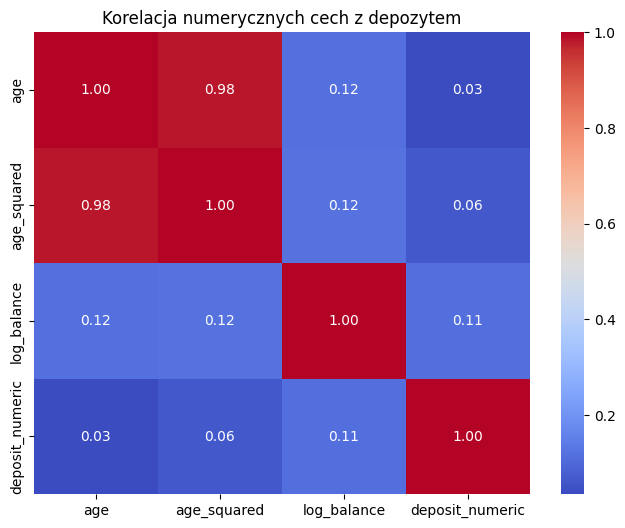

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# numeric features + target
numeric_cols = ['age', 'age_squared', 'log_balance', 'deposit_numeric']

corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelacja numerycznych cech z depozytem')
plt.show()

### Wnioski

1️⃣ Główne cechy (high importance) – silna korelacja z `deposit`

| Cecha                             | Typ / rola                    | Uzasadnienie                                                                                                                            |
| --------------------------------- | ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| `log_balance` / `balance_shifted` | Confounder                    | Silna korelacja z depozytem. Saldo wpływa na decyzję otwarcia depozytu i może wpływać na szansę bycia wybranym do kontaktu (treatment). |
| `age` / `age_squared`             | Confounder                    | Starsi klienci mają wyższe P(deposit). Można uwzględnić w propensity score lub jako kontrola w modelu.                                  |
| `was_contacted_before`            | Confounder / proxy propensity | Historia kontaktów wpływa na otwarcie depozytu i może korelować z treatment (czy klient dostał ofertę).                                 |
| `has_debt`                        | Confounder                    | Długi i zobowiązania finansowe wpływają na decyzję o depozycie i mogą być związane z treatment.                                         |
| `treatment`                       | Treatment                     | Główna zmienna wyjaśniająca – kontakt telefoniczny / kampania marketingowa.                                                             |
| `financial_stress`                | Confounder                    | Łączy saldo negatywne, pożyczki i default – wpływa na decyzję depozytu i treatment.                                                     |

**Wskazówka:** te zmienne **powinny iść do modelu** jako zmienne kontrolne lub do propensity score.

---

2️⃣ Średnie cechy (medium importance) – umiarkowana korelacja lub znaczenie

| Cecha                                 | Typ / rola                    | Uzasadnienie                                                                                         |
| ------------------------------------- | ----------------------------- | ---------------------------------------------------------------------------------------------------- |
| `pdays`                               | Post-treatment / collider     | Liczba dni od ostatniego kontaktu – użycie w modelu może wprowadzić bias, jeśli zależy od treatment. |
| `previous` / `contact_intensity_past` | Confounder / proxy propensity | Historia wcześniejszych kontaktów – umiarkowana korelacja z deposit i treatment.                     |
| `net_balance_indicator`               | Confounder                    | Informacja o dodatnim/ujemnym saldzie. Koreluje z log_balance, może wspomagać model.                 |
| `day` / `month_num`                   | Confounder sezonowy           | Data kontaktu – umiarkowany efekt sezonowości. Można uwzględnić jako kontrola w modelu.              |

---

3️⃣ Cechy do odrzucenia / ignorowania (low importance / risky)

| Cecha                               | Typ / rola                        | Uzasadnienie                                                                                                              |
| ----------------------------------- | --------------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| `duration` (już usunięta)           | Post-treatment                    | Czas rozmowy zależy od treatment i nie powinien być używany w modelu predykcyjnym do P(deposit).                          |
| `job`                               | Niska korelacja / wiele kategorii | Można zakodować w dummies, ale korelacja z targetem słaba → małe znaczenie w modelu causal.                               |
| `contact` (categorical, po dummies) | Post-treatment                    | Typ kontaktu (`unknown`, `cellular`) – jeśli traktujemy `treatment` jako `cellular`, może być kolidującym post-treatment. |
| `month_*` dummy variables           | Sezonowość – niska korelacja      | Niektóre miesiące mają korelację, ale efekt umiarkowany. Można opcjonalnie użyć jako kontrola sezonowa.                   |
| `education_*`, `marital_*`          | Niska korelacja z deposit         | Opcjonalnie jako zmienne kontrolne, ale słaba korelacja z targetem.                                                       |

---

🔑 Podsumowanie ról:

* **Confounder** → należy uwzględnić w modelu / propensity score: `log_balance`, `age`, `financial_stress`, `has_debt`, `was_contacted_before`, `previous/contact_intensity_past`.
* **Post-treatment / collider** → **nie używać w modelu przyczynowym**: `duration`, `pdays`, czasami `contact`.
* **Opcjonalne kontrolki** → średnia lub niska korelacja: `month_num`, `day`, `education_*`, `marital_*`, `job`.

### Zapis gotowego zbioru

In [23]:
import pandas as pd

# kolumny do zapisania (główne cechy + treatment + średnie cechy opcjonalnie)
columns_to_keep = [
    'log_balance',            # confounder
    'balance_shifted',        # confounder (alternatywnie lub dodatkowo)
    'age',                    # confounder
    'age_squared',            # confounder (opcjonalnie)
    'was_contacted_before',   # confounder / proxy propensity
    'has_debt',               # confounder
    'financial_stress',       # confounder
    'treatment',              # treatment
    'previous',               # medium importance / proxy propensity
    'net_balance_indicator',  # medium importance / confounder
    'day',                    # medium importance / sezonowość
    'month_num',              # średnia kontrola sezonowa
    'month_mar',
    'month_oct',
    'month_sep',
    'month_dec',
    'marital_single',
    'education_tertiary',
    'marital_married',
    'pdays',
    'deposit',
    'deposit_numeric',
    # 'pdays'                  # post-treatment – raczej pomijamy w modelu przyczynowym
]

df_selected = df[columns_to_keep].copy()

df_selected.to_csv("./data/processed/bank_selected.csv", index=False)

In [24]:
df_selected = df[columns_to_keep].copy()

df_selected.glimpse()

<class 'pandas.DataFrame'>: 11162 rows of 22 columns
log_balance:            float64           [9.12598002335811, 8.838261682 ...
balance_shifted:        int64             [9191, 6893, 8118, 9324, 7032, ...
age:                    int64             [59, 56, 41, 55, 54, 42, 56, 6 ...
age_squared:            int64             [3481, 3136, 1681, 3025, 2916, ...
was_contacted_before:   int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
has_debt:               int64             [1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...
financial_stress:       int64             [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...
treatment:              int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
previous:               int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
net_balance_indicator:  int64             [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...
day:                    int64             [5, 5, 5, 5, 5, 5, 6, 6, 6, 6, ...
month_num:              int64             [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...
month_mar:             